## File for Expanding model with user data


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import json
import cv2
import mediapipe as mp
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os
import sys
from pathlib import Path


In [5]:
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import utils as utils_module

data_folder = './Dataset'

data = []
labels = []

os.makedirs('./MP_DATA', exist_ok=True)
SAVE_PATH = './MP_DATA'
MODEL_PATH = './Models'

utils = utils_module.Utils()

In [6]:
# Initializing Mediapipe solutions for hand and pose detection
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=2, 
                       min_detection_confidence=0.5, 
                       min_tracking_confidence=0.5)

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(min_detection_confidence=0.5, 
                    min_tracking_confidence=0.5)


I0000 00:00:1756098864.309116   21783 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1756098864.317558   22000 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.1), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
I0000 00:00:1756098864.371114   21783 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1756098864.375483   22011 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.1), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)


W0000 00:00:1756098864.392416   21990 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Data Extraction


In [7]:
def process_hand(data_folder:str, hand_label:str) -> tuple:
    """Iterate through each class folder in the data directory"""
    for label in os.listdir(data_folder):
        class_folder = os.path.join(data_folder, label)
        
        if os.path.isdir(class_folder):
            # Iterate through each image in the class folder
            for image_name in os.listdir(class_folder):
                image_path = os.path.join(class_folder, image_name)
                
                image = cv2.imread(image_path)
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                results = hands.process(image_rgb)
                
                pose_results = pose.process(image_rgb)

                # If hands are detected, extract features for the specified hand
                if results.multi_hand_landmarks:
                    for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
                        if handedness.classification[0].label == hand_label:
                            if pose_results.pose_landmarks:
                                features = utils.extract_hand_features(hand_landmarks.landmark, pose_results.pose_landmarks.landmark)
                                data.append(features)
                                labels.append(label)
            
            return data, labels


def process_pose(data_folder):
    """
    Processes images in the data folder to extract pose features and labels.
    """
    data = []
    labels = []
    
    for label in os.listdir(data_folder):
        class_folder = os.path.join(data_folder, label)
        
        if os.path.isdir(class_folder):
            for image_name in os.listdir(class_folder):
                image_path = os.path.join(class_folder, image_name)
                
                image = cv2.imread(image_path)
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                results = pose.process(image_rgb)
                
                if results.pose_landmarks:
                    landmarks = results.pose_landmarks.landmark
                    features = utils.extract_pose_features(landmarks)
                    data.append(features)
                    labels.append(label)
    
    return data, labels



def merge_and_save_json(new_data, new_labels, json_path):
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            old = json.load(f)
        merged_data = old.get('data', []) + new_data
        merged_labels = old.get('labels', []) + new_labels
    else:
        merged_data = new_data
        merged_labels = new_labels
    with open(json_path, 'w') as f:
        json.dump({'data': merged_data, 'labels': merged_labels}, f)
    print(f"JSON file merged and saved at {json_path}")


In [8]:

LEFT_JSON  = rf'{SAVE_PATH}/left.json'
RIGHT_JSON = rf'{SAVE_PATH}/right.json'
POSE_JSON  = rf'{SAVE_PATH}/pose.json'

# Extracting data 
left_data, left_labels = process_hand(data_folder, 'Left')
right_data, right_labels = process_hand(data_folder, 'Right')
pose_data, pose_labels = process_pose(data_folder)

# Save the data and labels in JSON file
merge_and_save_json(left_data, left_labels, LEFT_JSON)
merge_and_save_json(right_data, right_labels, RIGHT_JSON)
merge_and_save_json(pose_data, pose_labels, POSE_JSON)

W0000 00:00:1756098864.441647   21988 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756098864.547413   22003 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756098864.607844   22007 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756098864.720350   21993 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


JSON file merged and saved at ./MP_DATA/left.json
JSON file merged and saved at ./MP_DATA/right.json
JSON file merged and saved at ./MP_DATA/pose.json


## Training


In [9]:

def compute_accuracy(y_true, y_pred):
    correct_predictions = sum(1 for true_label, predicted in zip(y_true, y_pred) if true_label == predicted)
    return correct_predictions / len(y_true)

def load_json_data(json_path):
    with open(json_path, 'r') as f:
        data_dict = json.load(f)
    X = np.array(data_dict['data'])
    y = np.array(data_dict['labels'])
    return X, y

def train_and_save_model_json(json_path, model_path):
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    X, y = load_json_data(json_path)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=True, stratify=y
    )
    
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_split=3,
        min_samples_leaf=2,
        bootstrap=True,
        criterion='entropy',
        oob_score=True
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = np.mean(y_pred == y_test)
    
    print(f"{model_path}: {acc * 100:.2f}% of samples classified correctly!")
    with open(model_path, 'wb') as f:
        pickle.dump({'model': model}, f)


# Function to plot confusion matrix from JSON data
def plot_conf_matrix_json(model_path, json_path, title):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)['model']
    with open(json_path, 'r') as f:
        data_dict = json.load(f)
    X = np.array(data_dict['data'])
    y = np.array(data_dict['labels'])
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=True, stratify=y
    )
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test),
                yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()



./Models/pose_model_json.p: 82.91% of samples classified correctly!
./Models/left_model_json.p: 90.77% of samples classified correctly!
./Models/right_model_json.p: 94.05% of samples classified correctly!


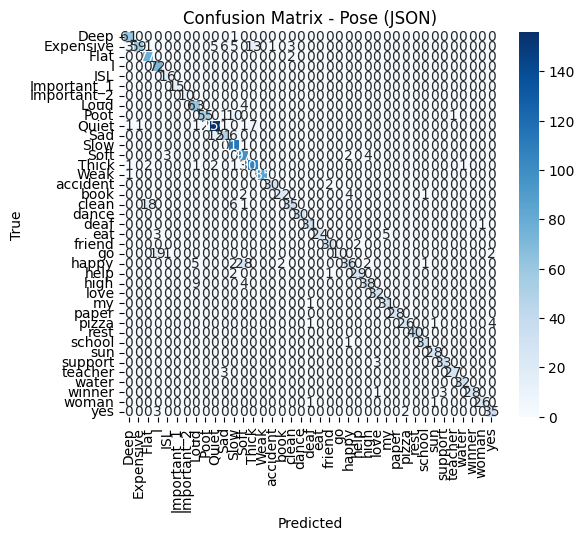

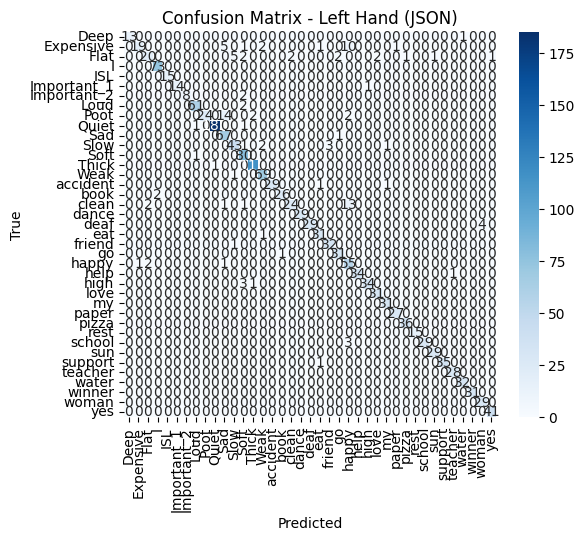

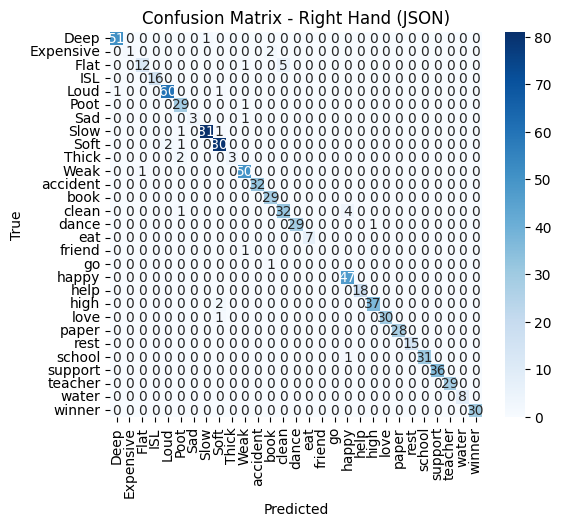

In [10]:
# Train and save all three models using JSON data files
train_and_save_model_json(f'{SAVE_PATH}/pose.json', f'{MODEL_PATH}/pose_model_json.p')
train_and_save_model_json(f'{SAVE_PATH}/left.json', f'{MODEL_PATH}/left_model_json.p')
train_and_save_model_json(f'{SAVE_PATH}/right.json', f'{MODEL_PATH}/right_model_json.p')

# plotting cof matrix
plot_conf_matrix_json(rf'{MODEL_PATH}/pose_model_json.p', rf'{SAVE_PATH}/pose.json', 'Pose (JSON)')
plot_conf_matrix_json(rf'{MODEL_PATH}/left_model_json.p', rf'{SAVE_PATH}/left.json', 'Left Hand (JSON)')
plot_conf_matrix_json(rf'{MODEL_PATH}/right_model_json.p', rf'{SAVE_PATH}/right.json', 'Right Hand (JSON)')
